# 14 · Cross-dataset transfer benchmark — the 1B (Llama-3.2-1B) fused detector

Same robustness test as **notebook 11**, but for the **1B** model's heads + fusion (`tag l1b`, trained in
nb13). For each of 4 datasets we generate *fresh* answers with the 1B, score the TriviaQA-trained
SEP / HalluShift / TSV heads, apply the 1B's fusion, and report the full metric set — **nothing is re-fit on
the targets**, so every row is held out.

- **Model under test:** `Llama-3.2-1B-Instruct` with its `sentence_l1b` heads.
- **Labels:** a **decoupled 8B judge** grades correctness (a 1B is too weak to grade itself) — substring-match
  handles the easy cases, the judge only rescues misses.
- **Robustness:** `tools/cross_eval.py` is now model-aware (HalluShift layer count derived from the cached
  feature width), so the exact 8B benchmark code runs the 1B unchanged.

Run in `se_probes_env` (GPU). The 1B and the 8B judge load one at a time per dataset.


In [1]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')
# Use the HF token cached by huggingface_hub.login; env-var tokens override it, so drop stale ones or the
# gated Llama-3.2 would 401 (same guard as nb13).
for _v in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN'):
    os.environ.pop(_v, None)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
print('paths set')


paths set


## 0 · Config
Swap the model / datasets / sample count here. `FUSION_PKL` is the 1B's **deployed** fused model (the headline);
`RANK_PKL` is the parameter-free rank-mean used only in the ablation.

In [2]:
# == CONFIG =================================================================================
MODEL_ID    = 'meta-llama/Llama-3.2-1B-Instruct'        # model under test (its l1b heads)
JUDGE_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'   # decoupled judge for labels (strong)
HEAD_SET    = 'sentence_l1b'                            # the 1B's per-sentence heads (artifacts *_sentence_l1b)
DATASETS    = ['triviaqa', 'squad', 'popqa', 'sciq']   # triviaqa held-out (offset 3000); the rest are transfer
N           = 100                                       # questions per dataset (use 50 for a quick smoke test)
OFFSETS     = {'triviaqa': 3000}                        # keep TriviaQA out of the heads' training range
FUSION_PKL  = 'models/fusion_claim_l1b.pkl'             # the 1B's DEPLOYED fused model -> the headline FUSED
RANK_PKL    = 'models/fusion_triviaqa_crosseval.pkl'    # parameter-free rank-mean (model-independent; ablation)
# ===========================================================================================
print(f'MODEL_ID={MODEL_ID}')
print(f'HEAD_SET={HEAD_SET} | DATASETS={DATASETS} | N={N} | FUSION_PKL={FUSION_PKL}')


MODEL_ID=meta-llama/Llama-3.2-1B-Instruct
HEAD_SET=sentence_l1b | DATASETS=['triviaqa', 'squad', 'popqa', 'sciq'] | N=100 | FUSION_PKL=models/fusion_claim_l1b.pkl


## 1 · Build the parameter-free rank-mean fusion (ablation only; model-independent)
Rank-mean has no weights and no training data, so the SAME artifact works for any model — we just (re)write it
here for the ablation cell. It does NOT touch the 1B's deployed `fusion_claim_l1b.pkl`.

In [3]:
from fit_crosseval_fusion import build
build()   # writes models/fusion_triviaqa_crosseval.pkl (rank-mean of within-dataset percentile ranks)


saved models\fusion_triviaqa_crosseval.pkl  (kind=rankmean, features=['sep_entropy', 'hallushift', 'tsv_margin'])
parameter-free rank-mean ensemble: fused = mean(within-dataset percentile rank of each detector)


## 2 · Run the benchmark (generate with the 1B → score l1b heads → fuse → label with the 8B judge)
GPU. Per dataset: the 1B generates fresh answers, its SEP/HalluShift/TSV heads score them, the 1B's fusion is
applied, and labels come from the decoupled 8B judge. The 1B and the 8B load one at a time (fits a T4).

In [4]:
import torch, psutil
print('VRAM GB:', round(torch.cuda.memory_allocated()/1e9,2),
      'reserved:', round(torch.cuda.memory_reserved()/1e9,2))
print('free GPU GB:', round(torch.cuda.mem_get_info()[0]/1e9,2))
print('free RAM GB:', round(psutil.virtual_memory().available/1e9,2))

from cross_eval import evaluate_many
SCORED = evaluate_many(DATASETS, train_ds='triviaqa', n=N, offsets=OFFSETS,
                       label_method='llm_judge', head_set=HEAD_SET,
                       model_name=MODEL_ID, judge_model=JUDGE_MODEL, fusion_pkl=FUSION_PKL)
print('done:', list(SCORED.keys()))


VRAM GB: 0.0 reserved: 0.0
free GPU GB: 11.79
free RAM GB: 8.16

############## triviaqa  (n=100, offset=3000) ##############
==== 1. generate + cache features on triviaqa (regime=sentence, labels=llm_judge) ====


Using the latest cached version of the dataset since trivia_qa couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'rc' at D:\LLAMA CACHE\huggingface\datasets\trivia_qa\rc\0.0.0\0f7faf33a3908546c6fd5b73a660e0f8ff173c2f (last modified on Wed Mar 18 11:01:14 2026).


[HallKing] loading meta-llama/Llama-3.2-1B-Instruct (4bit=True) ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 146/146 [00:08<00:00, 17.72it/s]


[HallKing] model ready | num_layers=16 | device=cuda:0


...

[HallKing] model unloaded.
  labels (llm_judge): truthful=58 halluc=42 (42.0%) over 100 answers
   n=100  balance: truthful=58 halluc=42 (42.0% halluc)
==== 2. score SEP + HalluShift heads (trained on triviaqa) ====
==== 3. score TSV head (trained on triviaqa) on Instruct model ====
[HallKing] loading meta-llama/Llama-3.2-1B-Instruct (4bit=True) ...


Loading weights: 100%|██████████| 146/146 [00:18<00:00,  8.07it/s]


[HallKing] model ready | num_layers=16 | device=cuda:0
[TSV] loaded checkpoint | layer=4 lam=5.0 cos_temp=0.1 | trained AUROC=0.7268


TSV scoring: 100%|██████████| 100/100 [00:03<00:00, 31.39q/s]


[HallKing] model unloaded.
==== 4. fusion + evaluation ====

=== sentence_l1b heads (triviaqa) -> sciq (transfer, all rows held out) ===
            AUROC   AUPR     F1
detector                       
SEP         0.664  0.565  0.667
HalluShift  0.685  0.537  0.673
TSV         0.580  0.472  0.636
FUSED       0.683  0.584  0.667

saved d:\Github Repositories\HallKing\data\sciq_cross_eval_sentence_l1b_claim_l1b.parquet
done: ['triviaqa', 'squad', 'popqa', 'sciq']


## 3 · Per-dataset metrics (AUROC / AUPR / Accuracy / Precision / Recall / F1)

In [5]:
import metrics as M
DETS = {'SEP':'sep_entropy', 'HalluShift':'hallushift', 'TSV':'tsv_margin', 'FUSED':'fused'}
METRICS = {}
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy()
    res = {}
    for name, col in DETS.items():
        s = df[col].to_numpy()
        m = M.detector_metrics(y, s, threshold=M.best_threshold(y, s))
        M.attach_curves(m, y, s)
        res[name] = m
    METRICS[ds] = res
    print(f'\n=== {ds}  (n={len(df)}, halluc={y.mean()*100:.1f}%) ===')
    print(M.summary_table(res).to_string())



=== triviaqa  (n=96, halluc=59.4%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7364  0.8469    0.5938     0.5938  1.0000  0.7451
HalluShift  0.8673  0.9055    0.8125     0.7826  0.9474  0.8571
TSV         0.7571  0.7981    0.7188     0.6829  0.9825  0.8058
FUSED       0.8016  0.8708    0.7292     0.6914  0.9825  0.8116

=== squad  (n=72, halluc=66.7%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7196  0.8085    0.7500     0.7419  0.9583  0.8364
HalluShift  0.7526  0.8176    0.7778     0.8200  0.8542  0.8367
TSV         0.6589  0.8100    0.6806     0.6761  1.0000  0.8067
FUSED       0.7413  0.8235    0.7778     0.7759  0.9375  0.8491

=== popqa  (n=48, halluc=70.8%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                              

## 4 · ROC / PR curves + confusion matrices per dataset

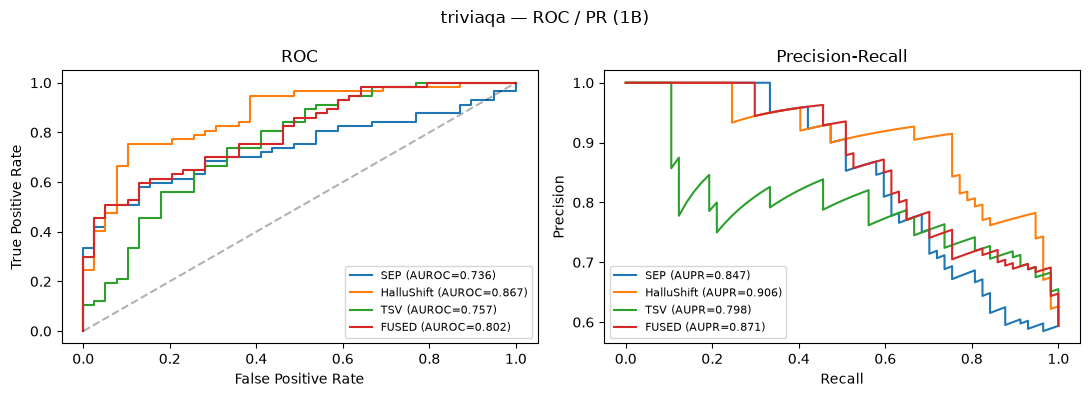

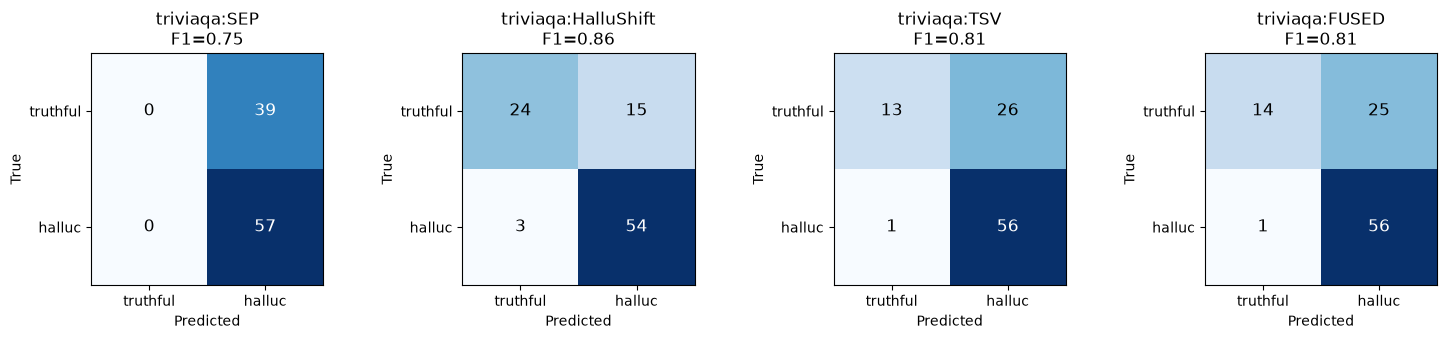

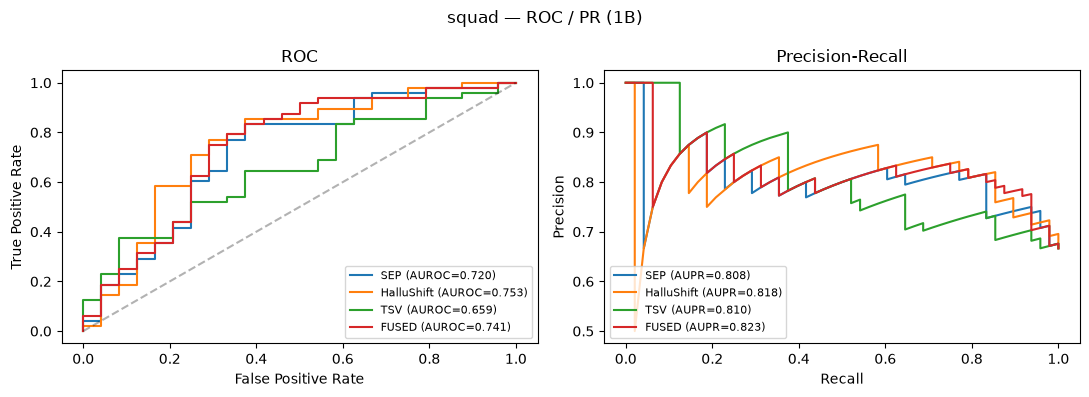

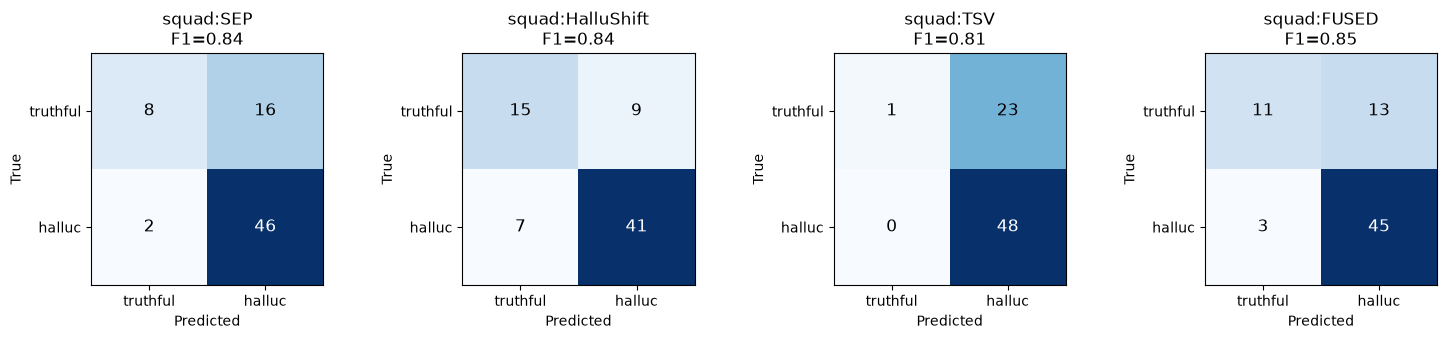

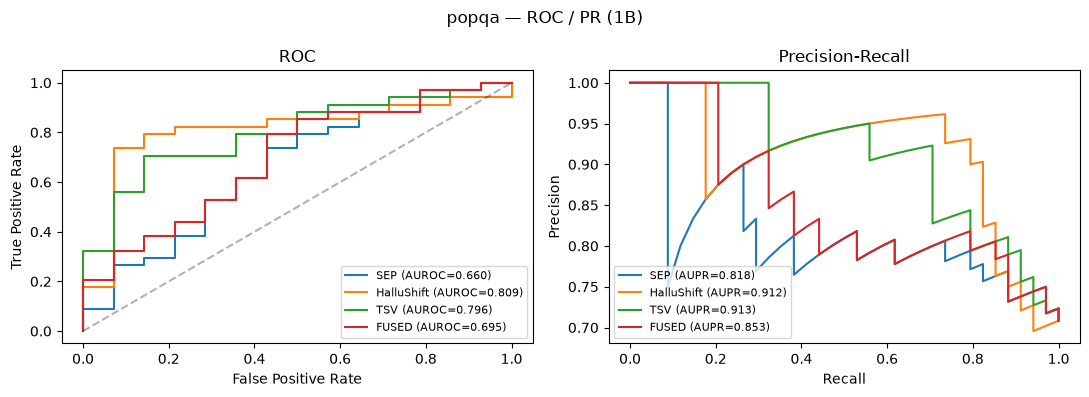

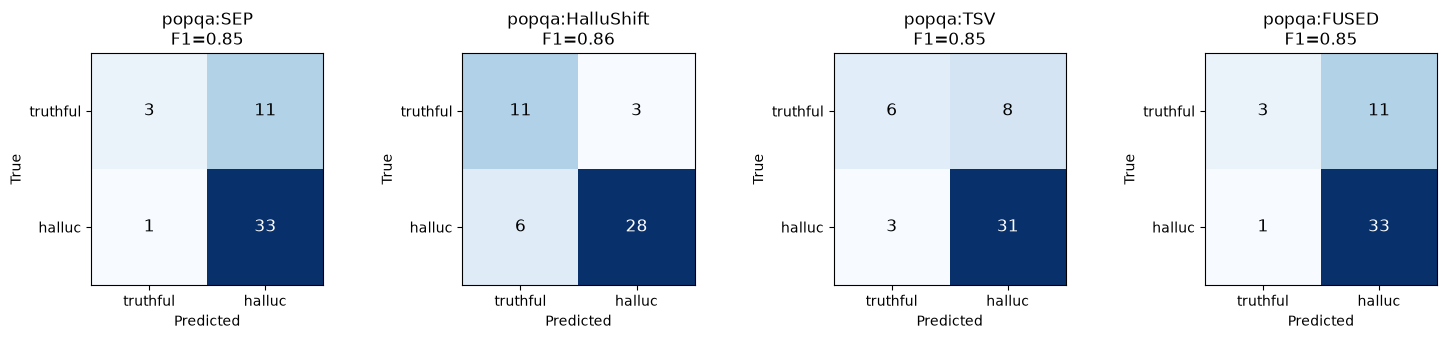

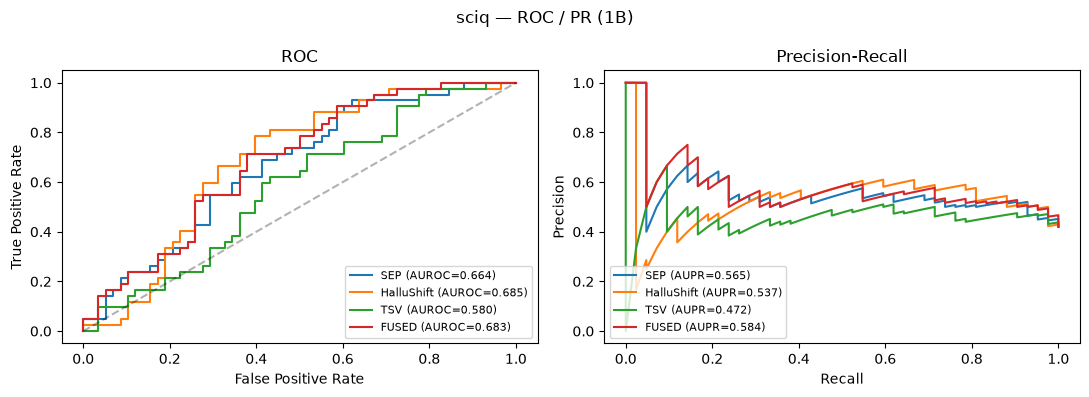

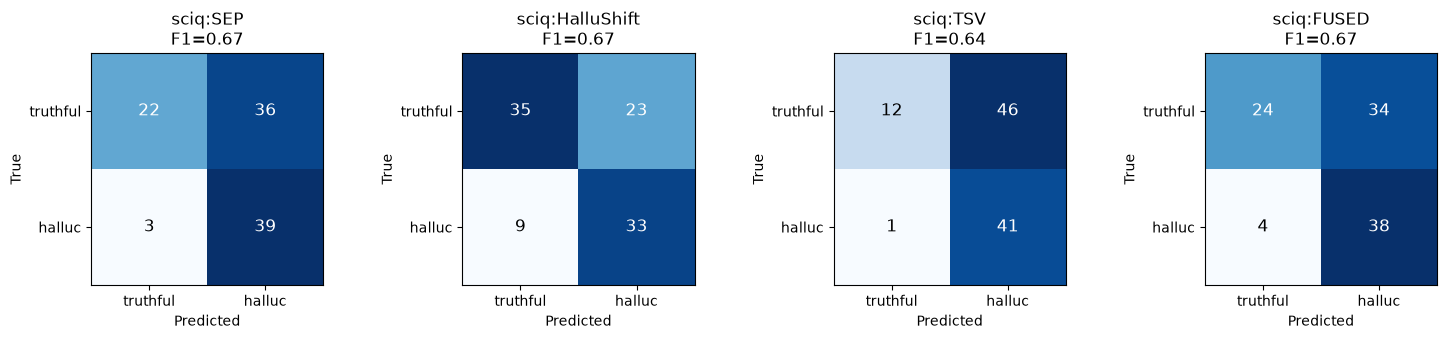

In [6]:
import metrics as M
import matplotlib.pyplot as plt
for ds, res in METRICS.items():
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
    fig.suptitle(f'{ds} — ROC / PR (1B)'); plt.tight_layout(); plt.show()
    fig, axes = plt.subplots(1, 4, figsize=(15,3.4))
    for axx,(name,m) in zip(axes, res.items()):
        M.plot_confusion(axx, m['confusion_matrix'], title=f"{ds}:{name}\nF1={m['F1']:.2f}")
    plt.tight_layout(); plt.show()


## 5 · Headline — does the 1B's FUSED detector stay on top across datasets?
Rows = dataset, cols = detector. Watch the **best single detector change** between rows while **FUSED stays
≥ the best single** — the robustness story for the 1B. `FUSED_wins` is True when fused ≥ the best individual head.

In [7]:
import pandas as pd
for metric in ['AUROC','AUPR','F1']:
    piv = pd.DataFrame({ds:{name:res[name][metric] for name in DETS}
                        for ds,res in METRICS.items()}).T.round(3)
    piv['best_single'] = piv[['SEP','HalluShift','TSV']].idxmax(axis=1)
    piv['FUSED_wins'] = piv['FUSED'] >= piv[['SEP','HalluShift','TSV']].max(axis=1)
    print(f'\n=== {metric} (rows=dataset, cols=detector) ===')
    print(piv.to_string())



=== AUROC (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa  0.736       0.867  0.757  0.802  HalluShift       False
squad     0.720       0.753  0.659  0.741  HalluShift       False
popqa     0.660       0.809  0.796  0.695  HalluShift       False
sciq      0.664       0.685  0.580  0.683  HalluShift       False

=== AUPR (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa  0.847       0.906  0.798  0.871  HalluShift       False
squad     0.808       0.818  0.810  0.823  HalluShift        True
popqa     0.818       0.912  0.913  0.853         TSV       False
sciq      0.565       0.537  0.472  0.584         SEP        True

=== F1 (rows=dataset, cols=detector) ===
            SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa  0.745       0.857  0.806  0.812  HalluShift       False
squad     0.836       0.837  0.807  0.849  HalluShift        True
popqa     0

## 6 · Ablation — the 1B's deployed logreg fusion vs parameter-free rank-mean
Both applied to the **same** held-out detector scores (no re-generation), isolating the fusion method. Shows
whether the 1B's logreg fusion (fit on TriviaQA sentences) holds up across datasets, or whether the
parameter-free rank-mean transfers better (the nb11 thesis, re-checked for the 1B).

In [8]:
from fusion import FusionModel
from sklearn.metrics import roc_auc_score
import os, pandas as pd
LOGREG = FusionModel.load(os.path.join('..', 'models', 'fusion_claim_l1b.pkl'))         # 1B deployed fusion
RANK   = FusionModel.load(os.path.join('..', 'models', 'fusion_triviaqa_crosseval.pkl'))  # rank-mean
F3 = ['sep_entropy', 'hallushift', 'tsv_margin']
rows = []
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy().astype(int)
    rows.append({'dataset': ds,
                 'FUSED_logreg_l1b': round(roc_auc_score(y, LOGREG.predict_proba(df[F3])), 3),
                 'FUSED_rankmean':   round(roc_auc_score(y, RANK.predict_proba(df[F3])), 3),
                 'best_single_head': round(max(roc_auc_score(y, df[c]) for c in F3), 3)})
ab = pd.DataFrame(rows).set_index('dataset')
print('AUROC — the 1B deployed logreg fusion vs the parameter-free rank-mean:')
print(ab.to_string())


AUROC — the 1B deployed logreg fusion vs the parameter-free rank-mean:
          FUSED_logreg_l1b  FUSED_rankmean  best_single_head
dataset                                                     
triviaqa             0.802           0.865             0.867
squad                0.741           0.748             0.753
popqa                0.695           0.785             0.809
sciq                 0.683           0.717             0.685
